<a href="https://colab.research.google.com/github/martinagonz/EvaluacionML/blob/version2/version2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Analisís Estadistico**
##Introducción
Este dataset contiene información sobre clientes de una empresa de ventas, incluyendo datos demográficos, hábitos de compra y respuestas a campañas de marketing el objetivo del análisis exploratorio de datos es enfocarce en estudiar el comportamiento de los clientes, considerando variables como ingresos, edad, nivel educativo, hábitos de compra y respuesta a campañas. A través de técnicas estadísticas y visualizaciones

In [3]:
# Importaciones de las librerias requeridas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configuración
plt.style.use('ggplot')
sns.set(style="whitegrid")
pd.set_option('display.max_columns', None)

#Cargamos el dataset

In [4]:
from google.colab import files
import pandas as pd # Importing the pandas library

uploaded = files.upload()
for fn in uploaded.keys():
    name=fn
df = pd.read_csv(name, sep="\t") # Now pd is defined and can be used
df.head(10)

Saving marketing_campaign.csv to marketing_campaign.csv


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0
5,7446,1967,Master,Together,62513.0,0,1,09-09-2013,16,520,42,98,0,42,14,2,6,4,10,6,0,0,0,0,0,0,3,11,0
6,965,1971,Graduation,Divorced,55635.0,0,1,13-11-2012,34,235,65,164,50,49,27,4,7,3,7,6,0,0,0,0,0,0,3,11,0
7,6177,1985,PhD,Married,33454.0,1,0,08-05-2013,32,76,10,56,3,1,23,2,4,0,4,8,0,0,0,0,0,0,3,11,0
8,4855,1974,PhD,Together,30351.0,1,0,06-06-2013,19,14,0,24,3,3,2,1,3,0,2,9,0,0,0,0,0,0,3,11,1
9,5899,1950,PhD,Together,5648.0,1,1,13-03-2014,68,28,0,6,1,1,13,1,1,0,0,20,1,0,0,0,0,0,3,11,0


In [5]:
# Información general del dataset
print("\nInformación general del dataset:")
df.info()




Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumD

#Estadistica Basica

In [6]:


# Descripción estadística básica
print("\nEstadísticas descriptivas básicas:")
df.describe()




Estadísticas descriptivas básicas:


,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [7]:

# Verificar valores nulos
print("\nCantidad de valores nulos por columna:")
df.isnull().sum()


Cantidad de valores nulos por columna:


,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


#Renombramos las variables para mayor claridad

In [8]:
df.rename(columns={
    'ID': 'ID',
    'Year_Birth': 'Año_Nacimiento',
    'Education': 'Educación',
    'Marital_Status': 'Estado_Civil',
    'Income': 'Ingresos',
    'Kidhome': 'Hijos_Pequeños',
    'Teenhome': 'Adolescentes',
    'Dt_Customer': 'Fecha_Registro',
    'Recency': 'Recencia',
    'MntWines': 'Gasto_Vinos',
    'MntFruits': 'Gasto_Frutas',
    'MntMeatProducts': 'Gasto_Carnes',
    'MntFishProducts': 'Gasto_Pescado',
    'MntSweetProducts': 'Gasto_Dulces',
    'MntGoldProds': 'Gasto_Productos_Lujo',
    'NumDealsPurchases': 'Compras_Descuento',
    'NumWebPurchases': 'Compras_Web',
    'NumCatalogPurchases': 'Compras_Catalogo',
    'NumStorePurchases': 'Compras_Tienda',
    'NumWebVisitsMonth': 'Visitas_Web_Mensuales',
    'AcceptedCmp3': 'Acepto_Campaña_3',
    'AcceptedCmp4': 'Acepto_Campaña_4',
    'AcceptedCmp5': 'Acepto_Campaña_5',
    'AcceptedCmp1': 'Acepto_Campaña_1',
    'AcceptedCmp2': 'Acepto_Campaña_2',
    'Complain': 'Reclamo',
    'Z_CostContact': 'Costo_Contacto',
    'Z_Revenue': 'Ingresos_Z',
    'Response': 'Respuesta'
}, inplace=True)

print(df.head(10))  # Muestra las primeras 10 filas con las columnas renombradas

     ID  Año_Nacimiento   Educación Estado_Civil  Ingresos  Hijos_Pequeños  \
0  5524            1957  Graduation       Single   58138.0               0   
1  2174            1954  Graduation       Single   46344.0               1   
2  4141            1965  Graduation     Together   71613.0               0   
3  6182            1984  Graduation     Together   26646.0               1   
4  5324            1981         PhD      Married   58293.0               1   
5  7446            1967      Master     Together   62513.0               0   
6   965            1971  Graduation     Divorced   55635.0               0   
7  6177            1985         PhD      Married   33454.0               1   
8  4855            1974         PhD     Together   30351.0               1   
9  5899            1950         PhD     Together    5648.0               1   

   Adolescentes Fecha_Registro  Recencia  Gasto_Vinos  Gasto_Frutas  \
0             0     04-09-2012        58          635            88   

# Identificación y descripción de variables

In [9]:
# Clasificación
print("\n--- Clasificación de variables ---")

# Variables cuantitativas
numericas_continuas = ['Ingresos', 'Recencia', 'Gasto_Vinos', 'Gasto_Frutas', 'Gasto_Carnes',
                       'Gasto_Pescado', 'Gasto_Dulces', 'Gasto_Productos_Lujo']
numericas_discretas = ['Año_Nacimiento', 'Hijos_Pequeños', 'Adolescentes', 'Fecha_Registro',
                       'Compras_Descuento', 'Compras_Web', 'Compras_Catalogo',
                       'Compras_Tienda', 'Visitas_Web_Mensuales', 'Acepto_Campaña_1',
                       'Acepto_Campaña_2', 'Acepto_Campaña_3', 'Acepto_Campaña_4', 'Acepto_Campaña_5',
                       'Reclamo', 'Respuesta']

# Variables cualitativas
categoricas_nominales = ['Estado_Civil', 'Educación'] # Updated column names
categoricas_ordinales = []

print("Variables numéricas continuas:", numericas_continuas)
print("Variables numéricas discretas:", numericas_discretas)
print("Variables categóricas nominales:", categoricas_nominales)
print("Variables categóricas ordinales:", categoricas_ordinales)

# Convertir variables categóricas al tipo correcto
for col in categoricas_nominales + categoricas_ordinales:
    df[col] = df[col].astype('category')


--- Clasificación de variables ---
Variables numéricas continuas: ['Ingresos', 'Recencia', 'Gasto_Vinos', 'Gasto_Frutas', 'Gasto_Carnes', 'Gasto_Pescado', 'Gasto_Dulces', 'Gasto_Productos_Lujo']
Variables numéricas discretas: ['Año_Nacimiento', 'Hijos_Pequeños', 'Adolescentes', 'Fecha_Registro', 'Compras_Descuento', 'Compras_Web', 'Compras_Catalogo', 'Compras_Tienda', 'Visitas_Web_Mensuales', 'Acepto_Campaña_1', 'Acepto_Campaña_2', 'Acepto_Campaña_3', 'Acepto_Campaña_4', 'Acepto_Campaña_5', 'Reclamo', 'Respuesta']
Variables categóricas nominales: ['Estado_Civil', 'Educación']
Variables categóricas ordinales: []


In [10]:
numerical_cols = ['Ingresos', 'Gasto_Vinos', 'Gasto_Frutas', 'Gasto_Carnes', 'Gasto_Pescado',
                     'Gasto_Dulces', 'Gasto_Productos_Lujo', 'Compras_Descuento', 'Compras_Web',
                     'Compras_Catalogo', 'Compras_Tienda', 'Visitas_Web_Mensuales']

# Media, Mediana y Desviación Estándar
df[numerical_cols].mean(), df[numerical_cols].median(), df[numerical_cols].std()

(Ingresos                 52247.251354
 Gasto_Vinos                303.935714
 Gasto_Frutas                26.302232
 Gasto_Carnes               166.950000
 Gasto_Pescado               37.525446
 Gasto_Dulces                27.062946
 Gasto_Productos_Lujo        44.021875
 Compras_Descuento            2.325000
 Compras_Web                  4.084821
 Compras_Catalogo             2.662054
 Compras_Tienda               5.790179
 Visitas_Web_Mensuales        5.316518
 dtype: float64,
 Ingresos                 51381.5
 Gasto_Vinos                173.5
 Gasto_Frutas                 8.0
 Gasto_Carnes                67.0
 Gasto_Pescado               12.0
 Gasto_Dulces                 8.0
 Gasto_Productos_Lujo        24.0
 Compras_Descuento            2.0
 Compras_Web                  4.0
 Compras_Catalogo             2.0
 Compras_Tienda               5.0
 Visitas_Web_Mensuales        6.0
 dtype: float64,
 Ingresos                 25173.076661
 Gasto_Vinos                336.597393
 Gasto_Fruta

#Datos utiles para analisis

In [11]:
# Verificar y tratar valores nulos
print("\nTotal de valores nulos por columna:")
null_values = df.isnull().sum()
print(null_values[null_values > 0])

# Vemos que la columna Ingresos tiene valores nulos (renamed from 'Income')
# Para este análisis, imputaremos con la mediana (más robusta a outliers)
df['Ingresos'] = df['Ingresos'].fillna(df['Ingresos'].median()) # Changed 'Income' to 'Ingresos'

# Convertir Fecha_Registro a datetime y extraer información útil
# 'Dt_Customer' was renamed to 'Fecha_Registro'
df['Fecha_Registro'] = pd.to_datetime(df['Fecha_Registro'], format='%d-%m-%Y')
df['Customer_Since_Days'] = (pd.Timestamp('2015-01-01') - df['Fecha_Registro']).dt.days
# Asumimos '2015-01-01' como fecha de referencia según el contexto del dataset

# Calcular edad a partir del año de nacimiento
df['Age'] = 2015 - df['Año_Nacimiento']  # Asumimos 2015 como año de referencia

# Calcular gasto total por cliente
df['TotalSpent'] = df['Gasto_Vinos'] + df['Gasto_Frutas'] + df['Gasto_Carnes'] + \
                  df['Gasto_Pescado'] + df['Gasto_Dulces'] + df['Gasto_Productos_Lujo']

# Calcular número total de hijos
df['TotalChildren'] = df['Hijos_Pequeños'] + df['Adolescentes']

# Calcular número total de compras
df['TotalPurchases'] = df['Compras_Descuento'] + df['Compras_Web'] + \
                      df['Compras_Catalogo'] + df['Compras_Tienda']



# Verificar que no queden valores nulos
print("\nVerificación final de valores nulos:")
print(df.isnull().sum().sum())


Total de valores nulos por columna:
Ingresos    24
dtype: int64

Verificación final de valores nulos:
0


#Analisis Descriptivo


Si la prueba encuentra una diferencia significativa (valor p < 0.05), se podría concluir que, en promedio, las personas con doctorado tienen ingresos diferentes a las personas con título de graduación.

In [13]:


grad = df[df['Educación'] == 'Graduation']['Ingresos'].dropna()
phd = df[df['Educación'] == 'PhD']['Ingresos'].dropna()

t_stat, p_value = stats.ttest_ind(grad, phd, equal_var=False)
print(f"Prueba t para ingresos: t = {t_stat:.2f}, p = {p_value:.4f}")
if p_value < 0.05:
    print("Diferencia estadísticamente significativa")
else:
    print("No hay diferencia significativa")

Prueba t para ingresos: t = -2.71, p = 0.0068
Diferencia estadísticamente significativa


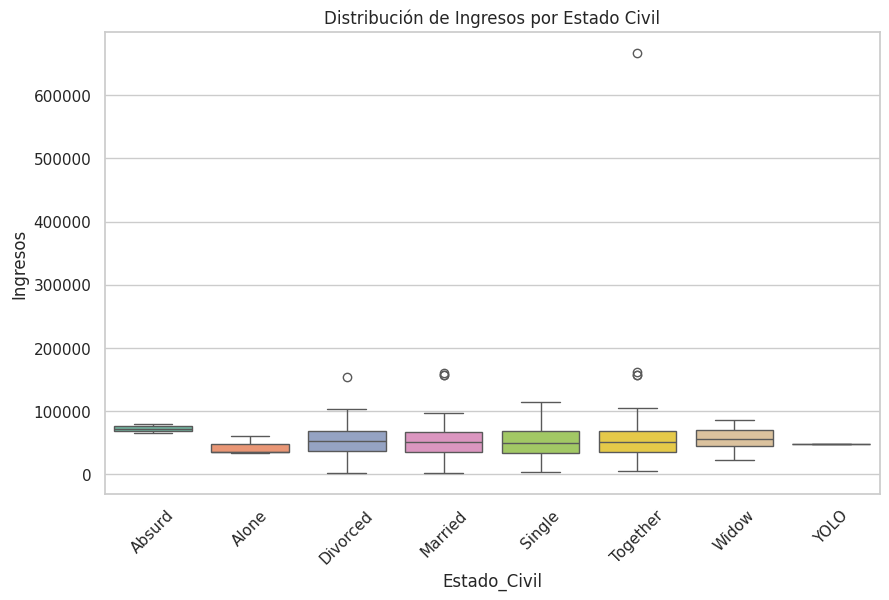

In [85]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Estado_Civil', y='Ingresos', data=df,  palette='Set2')  # Changed 'Marital_Status' to 'Estado_Civil' and 'Income' to 'Ingresos'
plt.title('Distribución de Ingresos por Estado Civil')
plt.xticks(rotation=45)
plt.show()

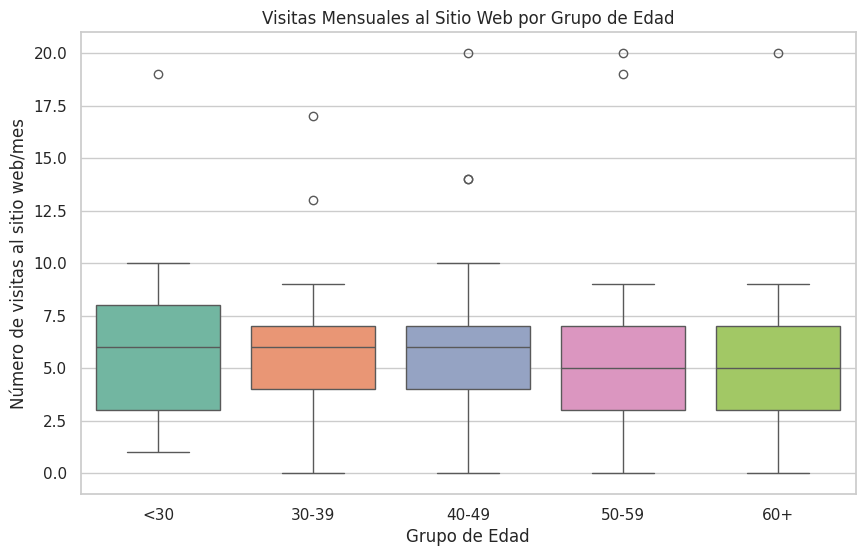

In [88]:
# Crear grupos de edad
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 30, 40, 50, 60, 100],
                        labels=['<30', '30-39', '40-49', '50-59', '60+'])

plt.figure(figsize=(10, 6))
# The column name should likely be 'Visitas_Web_Mensuales'
sns.boxplot(x='Age_Group', y='Visitas_Web_Mensuales', data=df,  palette='Set2')
plt.title('Visitas Mensuales al Sitio Web por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Número de visitas al sitio web/mes')
plt.show()

In [31]:
# Frecuencias para variables categóricas
# Change 'Education' to 'Educación' and 'Marital_Status' to 'Estado_Civil'
cat_cols = ['Educación', 'Estado_Civil', 'Respuesta']
for col in cat_cols:
    print(f"\nDistribución de {col}:")
    display(df[col].value_counts(normalize=True) * 100)


Distribución de Educación:


,proportion
Educación,
Graduation,50.312500
PhD,21.696429
Master,16.517857
2n Cycle,9.062500
Basic,2.410714



Distribución de Estado_Civil:


,proportion
Estado_Civil,
Married,38.571429
Together,25.892857
Single,21.428571
Divorced,10.357143
Widow,3.437500
Alone,0.133929
Absurd,0.089286
YOLO,0.089286



Distribución de Respuesta:


,proportion
Respuesta,
0,85.089286
1,14.910714


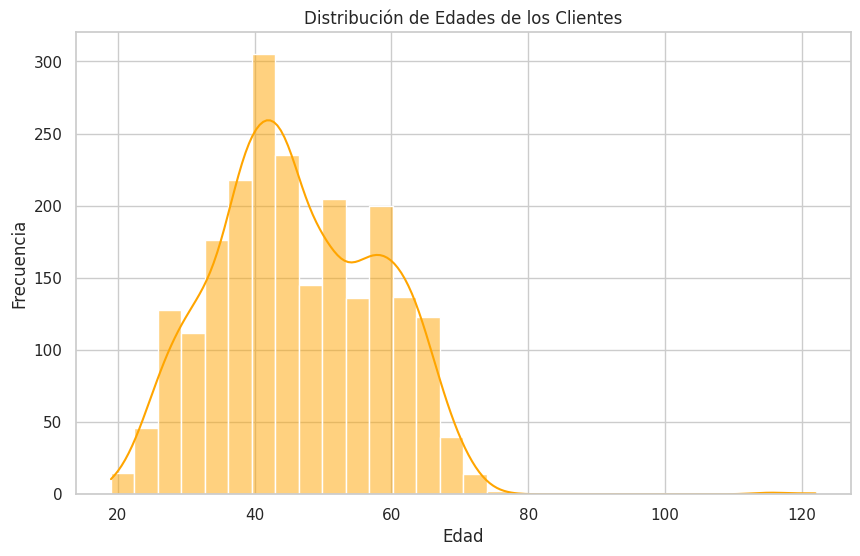

In [92]:
plt.figure(figsize=(10, 6))
# Ensure 'Age' (or 'Edad' if you renamed it) is in the DataFrame
if 'Edad' not in df.columns:
    df['Edad'] = 2015 - df['Año_Nacimiento']  # Recalculate 'Edad' if necessary

# Use the correct column name 'Edad' in the histplot
# The color argument is for the histogram bars, not the KDE line.
# Use line_kws to set the color of the KDE line.
sns.histplot(df['Edad'], bins=30, kde=True, color='orange')
plt.title('Distribución de Edades de los Clientes')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

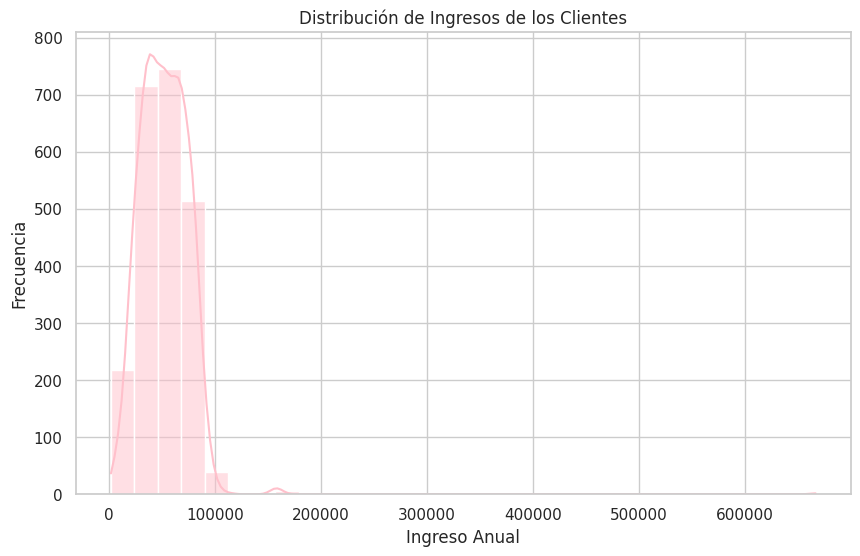

In [93]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Ingresos'], bins=30, kde=True, color='pink')
plt.title('Distribución de Ingresos de los Clientes')
plt.xlabel('Ingreso Anual')
plt.ylabel('Frecuencia')
plt.show()

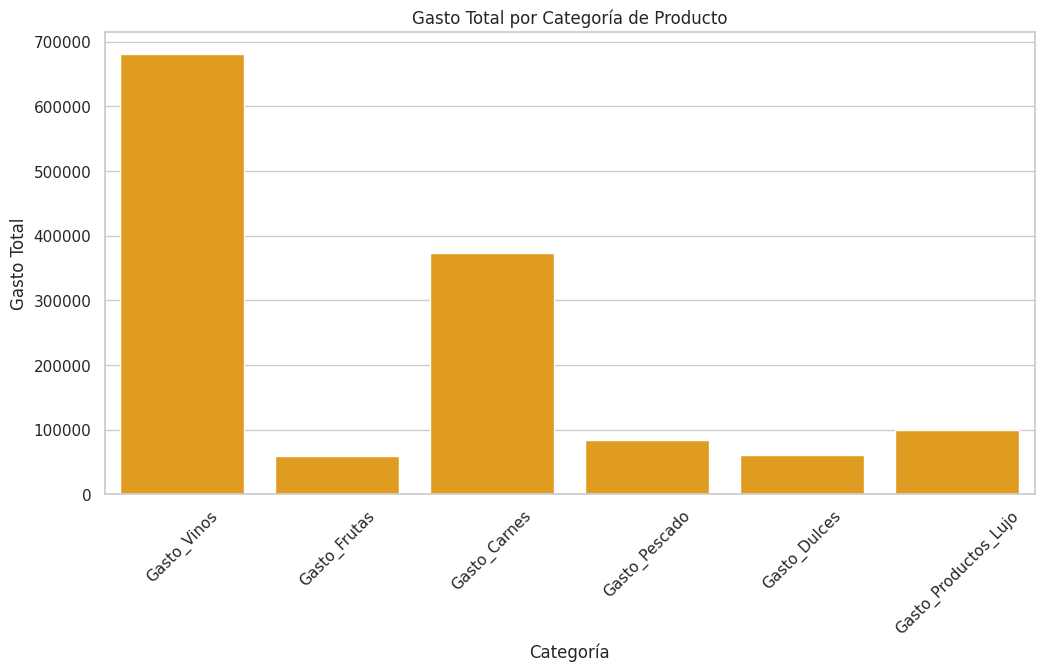

In [94]:
mnt_cols = ['Gasto_Vinos', 'Gasto_Frutas', 'Gasto_Carnes', 'Gasto_Pescado', 'Gasto_Dulces', 'Gasto_Productos_Lujo']  # Use the renamed column names
mnt_data = df[mnt_cols].sum().reset_index()
mnt_data.columns = ['Category', 'Total_Spent']

plt.figure(figsize=(12, 6))
sns.barplot(x='Category', y='Total_Spent', data=mnt_data, color='orange' )
plt.title('Gasto Total por Categoría de Producto')
plt.xlabel('Categoría')
plt.ylabel('Gasto Total')
plt.xticks(rotation=45)
plt.show()

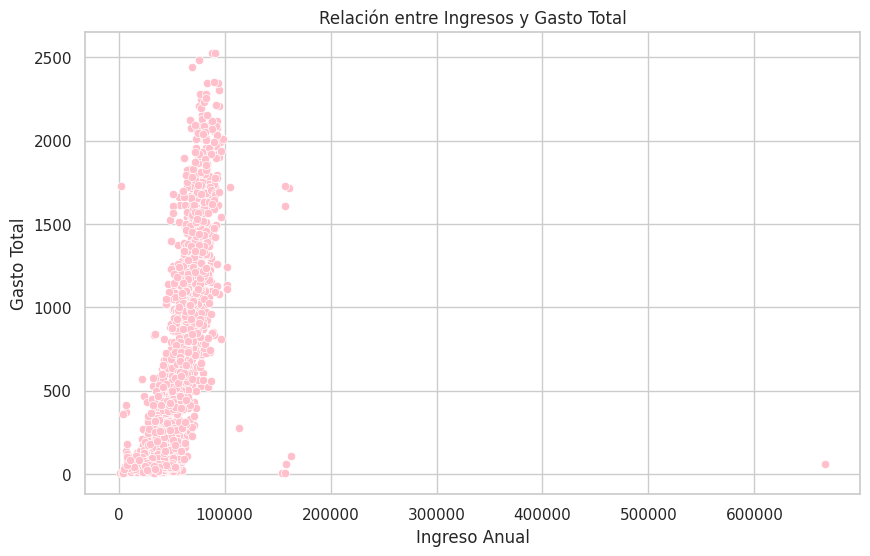

In [95]:
plt.figure(figsize=(10, 6))
# Change 'Income' to 'Ingresos' to match the renamed column
sns.scatterplot(x='Ingresos', y='TotalSpent', data=df, color='pink')
plt.title('Relación entre Ingresos y Gasto Total')
plt.xlabel('Ingreso Anual')
plt.ylabel('Gasto Total')
plt.show()

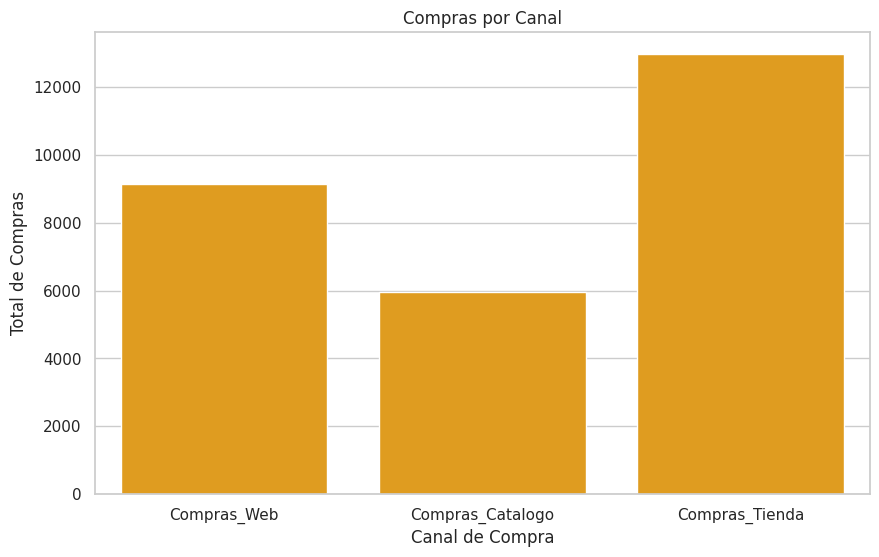

In [97]:
purchase_cols = ['Compras_Web', 'Compras_Catalogo', 'Compras_Tienda']  # Use the renamed column names
purchase_data = df[purchase_cols].sum().reset_index()
purchase_data.columns = ['Channel', 'Total_Purchases']

plt.figure(figsize=(10, 6))
sns.barplot(x='Channel', y='Total_Purchases', data=purchase_data, color='orange')
plt.title('Compras por Canal')
plt.xlabel('Canal de Compra')
plt.ylabel('Total de Compras')
plt.show()

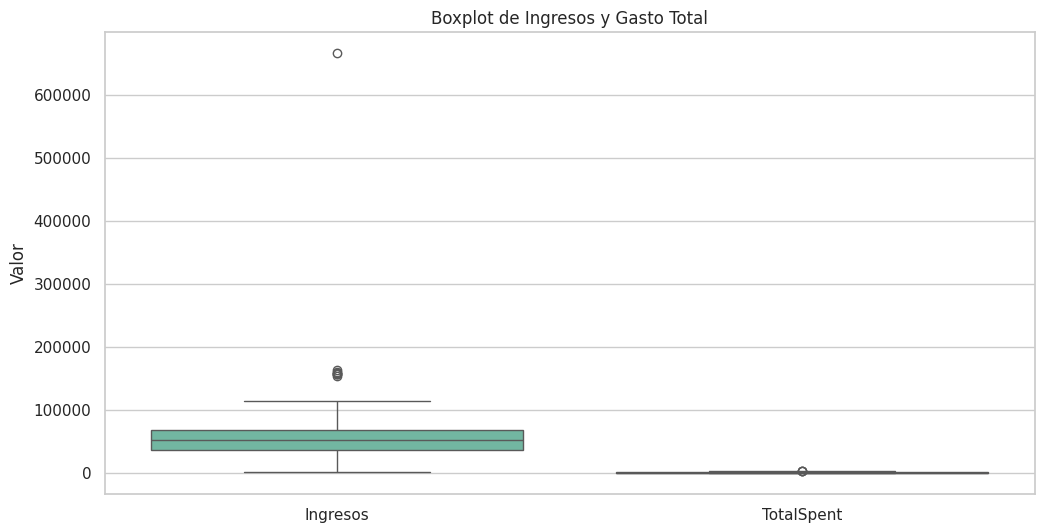

In [98]:
plt.figure(figsize=(12, 6))
# Use the correct column names: 'Ingresos' instead of 'Income'
sns.boxplot(data=df[['Ingresos', 'TotalSpent']], palette='Set2')
plt.title('Boxplot de Ingresos y Gasto Total')
plt.ylabel('Valor')
plt.show()

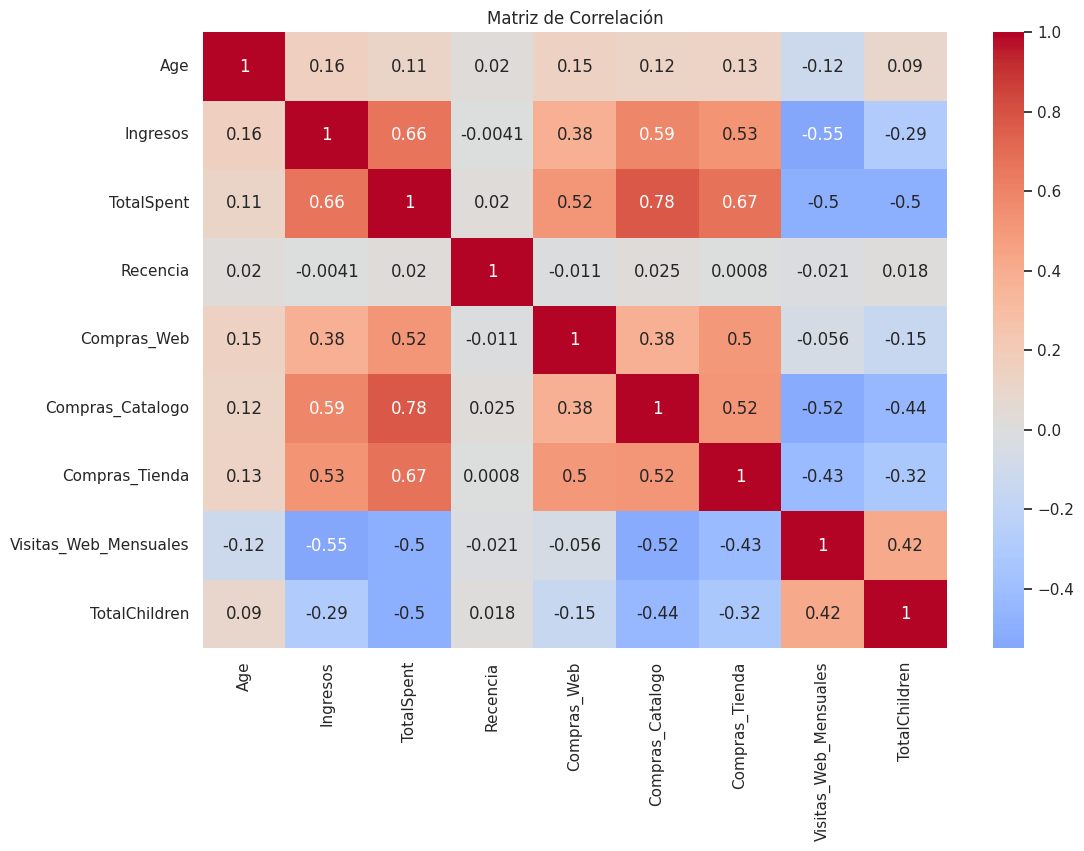

In [43]:
# Matriz de correlación
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación')
plt.show()

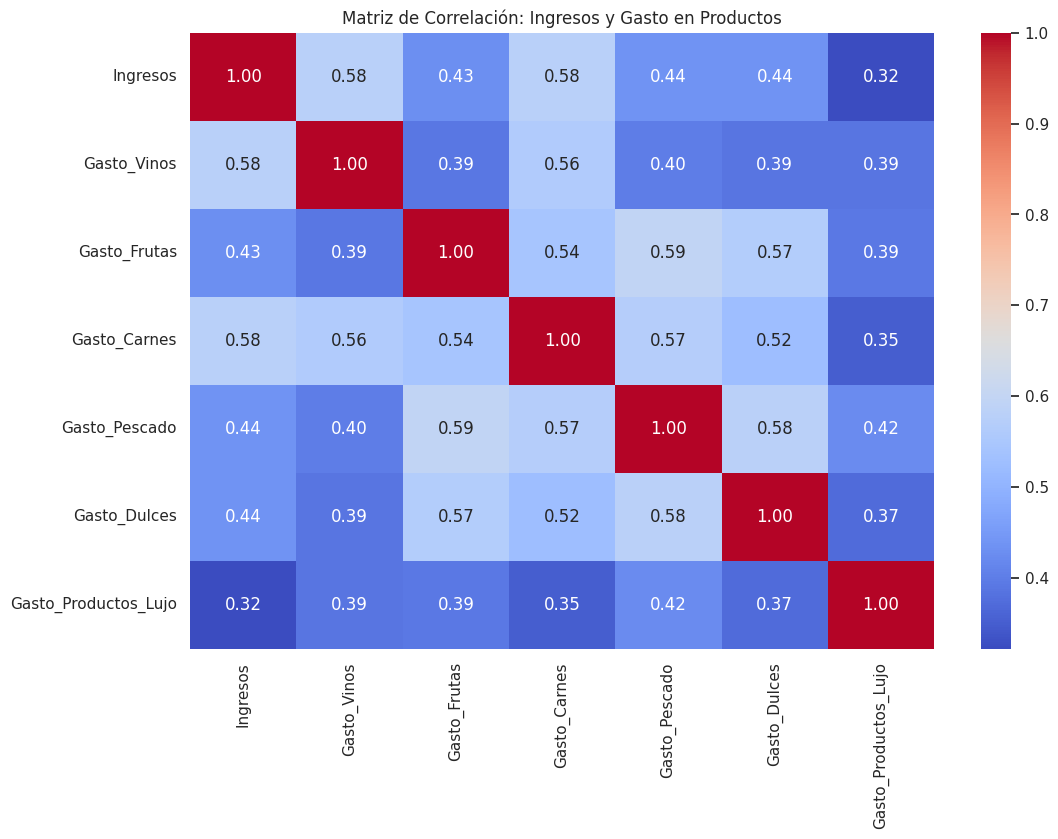

In [114]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionar las columnas relevantes para la matriz de correlación
cols_correlacion = ['Ingresos', 'Gasto_Vinos', 'Gasto_Frutas', 'Gasto_Carnes', 'Gasto_Pescado', 'Gasto_Dulces', 'Gasto_Productos_Lujo']

# Calcular la matriz de correlación
matriz_correlacion = df[cols_correlacion].corr()

# Crear el mapa de calor (heatmap)
plt.figure(figsize=(12, 8))  # Ajustar el tamaño de la figura si es necesario
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación: Ingresos y Gasto en Productos')
plt.show()

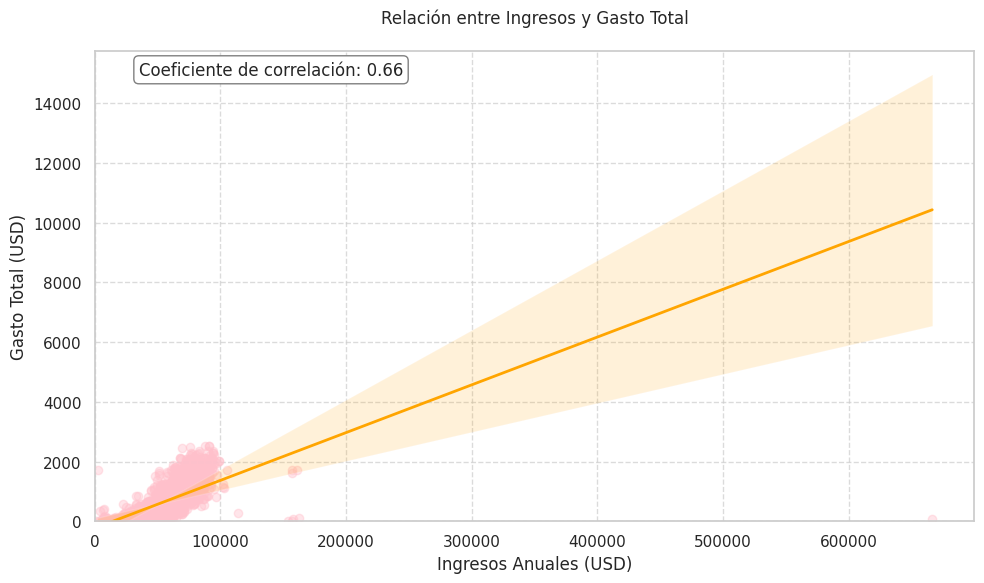

In [82]:
plt.figure(figsize=(10, 6))
ax = sns.regplot(x='Ingresos', y='TotalSpent', data=df,  # Changed 'Income' to 'Ingresos'
                 scatter_kws={'alpha':0.4, 'color':'pink'},
                 line_kws={'color':'orange', 'linewidth':2})

# Calcular y mostrar coeficiente de correlación
corr = df['Ingresos'].corr(df['TotalSpent'])  # Changed 'Income' to 'Ingresos'
plt.annotate(f'Coeficiente de correlación: {corr:.2f}',
             xy=(0.05, 0.95), xycoords='axes fraction',
             bbox=dict(boxstyle="round", fc="white", ec="gray"))

# Añadir etiquetas y título
plt.title('Relación entre Ingresos y Gasto Total', pad=20)
plt.xlabel('Ingresos Anuales (USD)')
plt.ylabel('Gasto Total (USD)')
plt.grid(True, linestyle='--', alpha=0.7)

# Ajustar límites para mejor visualización
plt.xlim(left=0)
plt.ylim(bottom=0)

plt.tight_layout()
plt.savefig('relacion_ingresos_gasto.png', dpi=300, bbox_inches='tight')
plt.show()

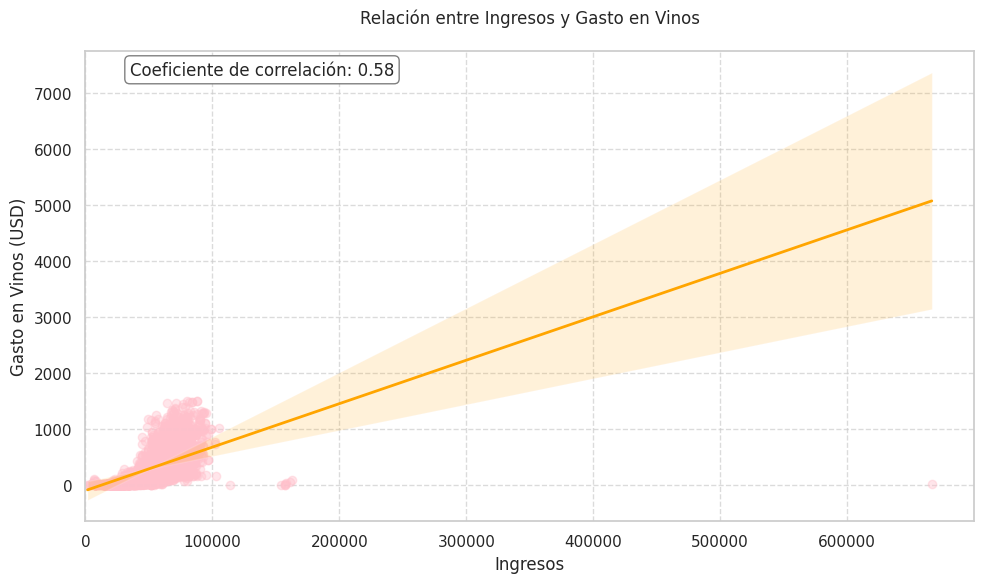

In [112]:
plt.figure(figsize=(10, 6))
ax = sns.regplot(x='Ingresos', y='Gasto_Vinos', data=df,
                 scatter_kws={'alpha':0.4, 'color':'pink'},
                 line_kws={'color':'orange', 'linewidth':2})

# Calcular y mostrar coeficiente de correlación
corr = df['Ingresos'].corr(df['Gasto_Vinos'])
plt.annotate(f'Coeficiente de correlación: {corr:.2f}',
             xy=(0.05, 0.95), xycoords='axes fraction',
             bbox=dict(boxstyle="round", fc="white", ec="gray"))

# Añadir etiquetas y título
plt.title('Relación entre Ingresos y Gasto en Vinos', pad=20)
plt.xlabel('Ingresos')
plt.ylabel('Gasto en Vinos (USD)')
plt.grid(True, linestyle='--', alpha=0.7)

# Ajustar límites para mejor visualización (opcional)
plt.xlim(left=0)  # Para que el eje x comience en 0
# plt.ylim(bottom=0)  # Si es necesario

plt.tight_layout()
plt.show()

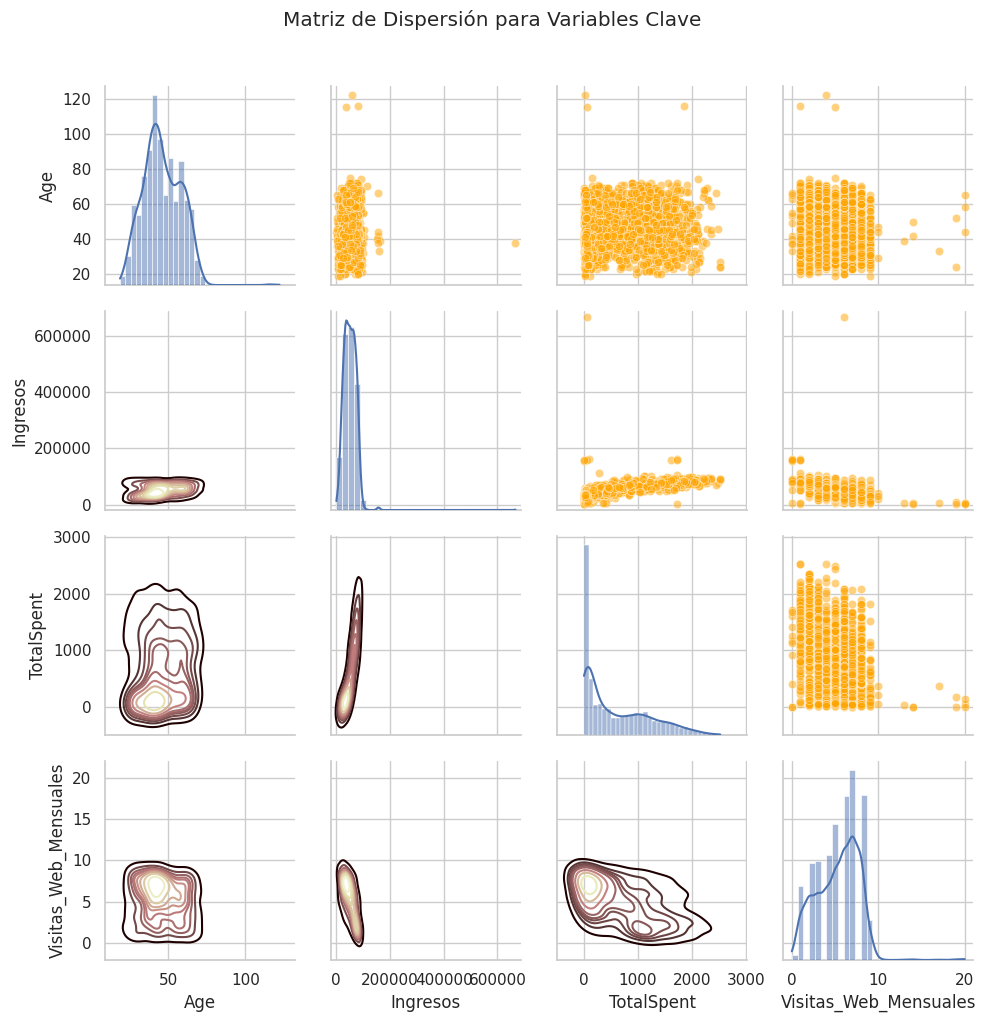

In [113]:
# Seleccionar variables clave
# Use the correct column names: 'Ingresos', 'TotalSpent', 'Visitas_Web_Mensuales'
scatter_vars = ['Age', 'Ingresos', 'TotalSpent', 'Visitas_Web_Mensuales']

# Crear matriz de dispersión con histogramas en diagonal
g = sns.PairGrid(df[scatter_vars], diag_sharey=False)
g.map_upper(sns.scatterplot, alpha=0.5, color='orange')
g.map_lower(sns.kdeplot, cmap='pink', palette='Set2')
g.map_diag(sns.histplot, kde=True, bins=30)

# Añadir título
plt.suptitle('Matriz de Dispersión para Variables Clave', y=1.02)
plt.tight_layout()
plt.savefig('matriz_dispersion.png', dpi=300, bbox_inches='tight')
plt.show()

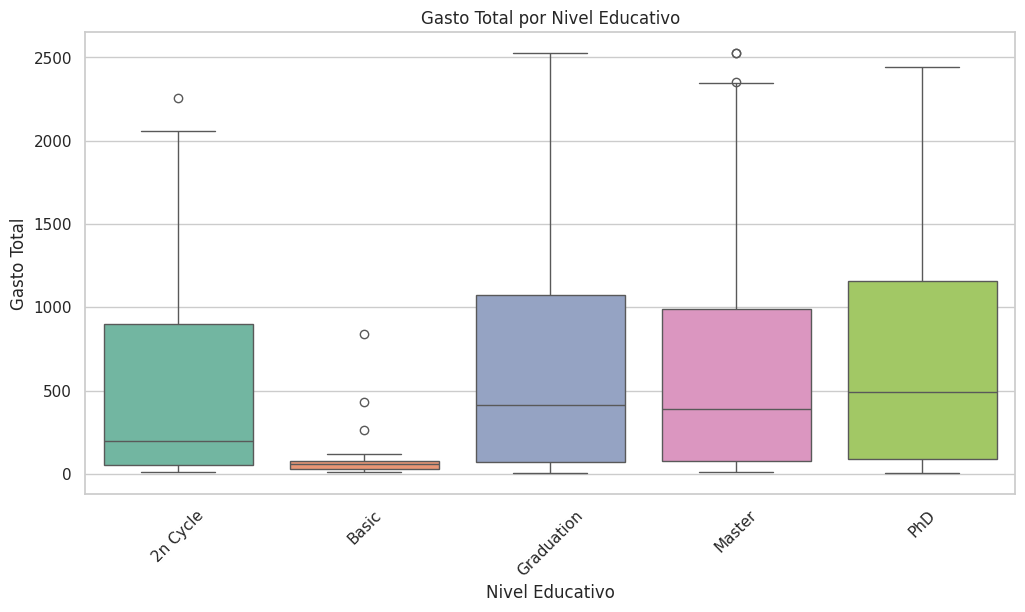

In [99]:
plt.figure(figsize=(12, 6))
# Change 'Education' to 'Educación' to match the renamed column
sns.boxplot(x='Educación', y='TotalSpent', data=df, palette='Set2')
plt.title('Gasto Total por Nivel Educativo')
plt.xlabel('Nivel Educativo')
plt.ylabel('Gasto Total')
plt.xticks(rotation=45)
plt.show()

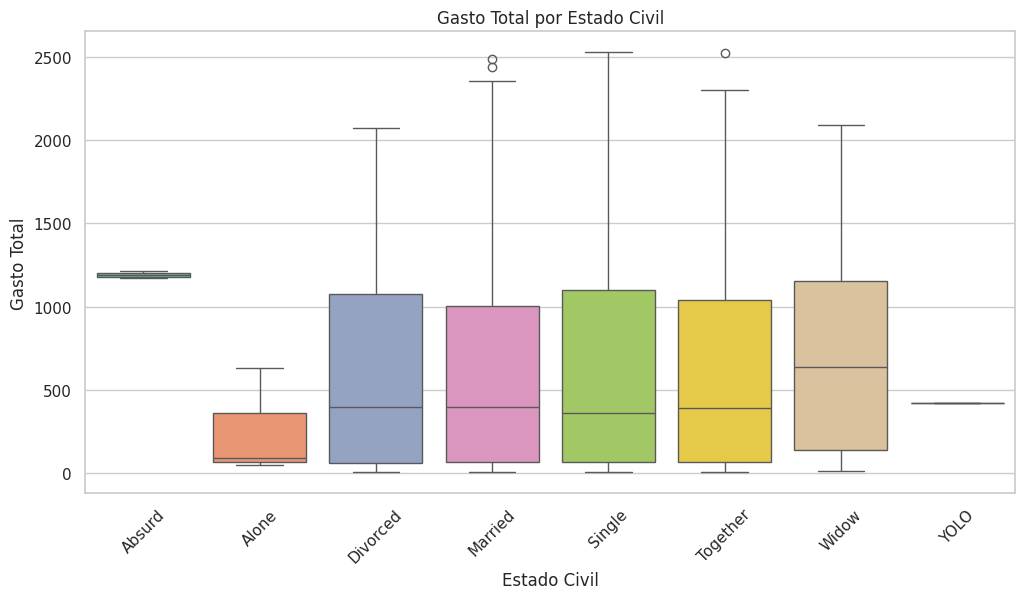

In [100]:
plt.figure(figsize=(12, 6))
# Changed 'Marital_Status' to 'Estado_Civil' to match the renamed column
sns.boxplot(x='Estado_Civil', y='TotalSpent', data=df, palette='Set2')
plt.title('Gasto Total por Estado Civil')
plt.xlabel('Estado Civil')
plt.ylabel('Gasto Total')
plt.xticks(rotation=45)
plt.show()

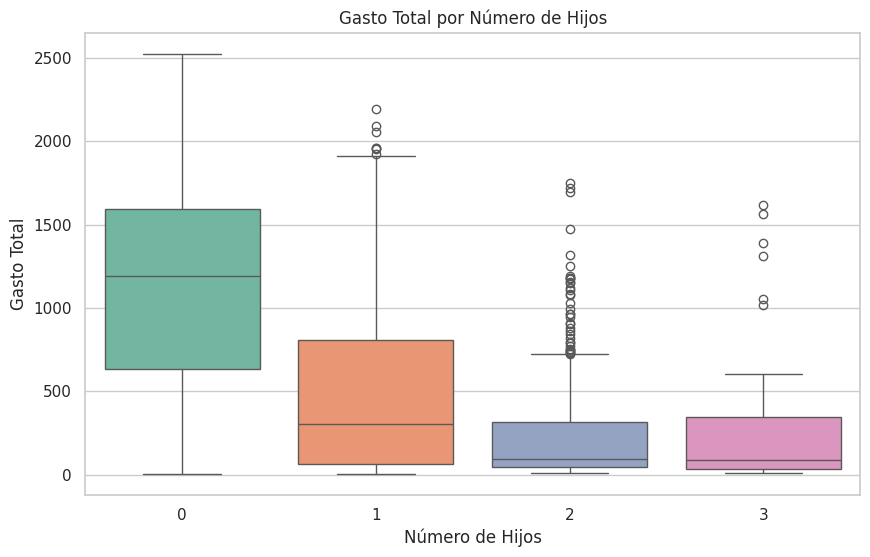

In [101]:
# Ensure 'Total_Children' column exists
df['TotalChildren'] = df['Hijos_Pequeños'] + df['Adolescentes']

plt.figure(figsize=(10, 6))
sns.boxplot(x='TotalChildren', y='TotalSpent', data=df, palette='Set2')  # Now use 'TotalChildren'
plt.title('Gasto Total por Número de Hijos')
plt.xlabel('Número de Hijos')
plt.ylabel('Gasto Total')
plt.show()

In [47]:
# Función para identificar outliers con el método IQR
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

# Outliers en Ingresos # Changed 'Income' to 'Ingresos'
income_outliers = detect_outliers(df, 'Ingresos')
print(f"Número de outliers en Ingresos: {len(income_outliers)}")

# Outliers en TotalSpent # Changed 'Total_Spent' to 'TotalSpent'
spent_outliers = detect_outliers(df, 'TotalSpent')
print(f"Número de outliers en TotalSpent: {len(spent_outliers)}")

Número de outliers en Ingresos: 8
Número de outliers en TotalSpent: 3


#Probabilidades

In [54]:
# Tabla de frecuencia absoluta y relativa
education_freq = df['Educación'].value_counts().reset_index()
education_freq.columns = ['Educación', 'Frecuencia_Absoluta']
education_freq['Frecuencia_Relativa'] = (education_freq['Frecuencia_Absoluta'] / len(df)) * 100
education_freq['Frecuencia_Relativa'] = education_freq['Frecuencia_Relativa'].round(2)

print("Tabla de Frecuencia - Nivel Educativo")
display(education_freq)

Tabla de Frecuencia - Nivel Educativo


,Educación,Frecuencia_Absoluta,Frecuencia_Relativa
0,Graduation,1127,50.31
1,PhD,486,21.70
2,Master,370,16.52
3,2n Cycle,203,9.06
4,Basic,54,2.41


In [56]:
marital_freq = df['Estado_Civil'].value_counts().reset_index()  # Changed 'Marital_Status' to 'Estado_Civil'
marital_freq.columns = ['Estado_Civil', 'Frecuencia_Absoluta']
marital_freq['Frecuencia_Relativa'] = (marital_freq['Frecuencia_Absoluta'] / len(df)) * 100
marital_freq['Frecuencia_Relativa'] = marital_freq['Frecuencia_Relativa'].round(2)

print("\nTabla de Frecuencia - Estado Civil")
display(marital_freq)


Tabla de Frecuencia - Estado Civil


,Estado_Civil,Frecuencia_Absoluta,Frecuencia_Relativa
0,Married,864,38.57
1,Together,580,25.89
2,Single,480,21.43
3,Divorced,232,10.36
4,Widow,77,3.44
5,Alone,3,0.13
6,Absurd,2,0.09
7,YOLO,2,0.09


In [58]:
response_freq = df['Respuesta'].value_counts().reset_index()
response_freq.columns = ['Respuesta', 'Frecuencia_Absoluta']
response_freq['Frecuencia_Relativa'] = (response_freq['Frecuencia_Absoluta'] / len(df)) * 100
response_freq['Frecuencia_Relativa'] = response_freq['Frecuencia_Relativa'].round(2)

print("\nTabla de Frecuencia - Respuesta a Campaña")
display(response_freq)


Tabla de Frecuencia - Respuesta a Campaña


,Respuesta,Frecuencia_Absoluta,Frecuencia_Relativa
0,0,1906,85.09
1,1,334,14.91


In [61]:
# Crear tabla de contingencia
# Change 'Education' to 'Educación' to match the renamed column
education_response = pd.crosstab(df['Educación'], df['Respuesta'], normalize='index') * 100
education_response = education_response.round(2)

print("\nProbabilidad de Respuesta por Nivel Educativo (%):")
display(education_response)


Probabilidad de Respuesta por Nivel Educativo (%):


Respuesta,0,1
Educación,,
2n Cycle,89.16,10.84
Basic,96.30,3.70
Graduation,86.51,13.49
Master,84.59,15.41
PhD,79.22,20.78


In [63]:
marital_response = pd.crosstab(df['Estado_Civil'], df['Respuesta'], normalize='index') * 100  # Changed 'Marital_Status' to 'Estado_Civil' and 'Response' to 'Respuesta'
marital_response = marital_response.round(2)

print("\nProbabilidad de Respuesta por Estado Civil (%):")
display(marital_response)


Probabilidad de Respuesta por Estado Civil (%):


Respuesta,0,1
Estado_Civil,,
Absurd,50.00,50.00
Alone,66.67,33.33
Divorced,79.31,20.69
Married,88.66,11.34
Single,77.92,22.08
Together,89.66,10.34
Widow,75.32,24.68
YOLO,50.00,50.00


In [65]:
children_freq = df['TotalChildren'].value_counts().reset_index()
children_freq.columns = ['Num_Hijos', 'Frecuencia_Absoluta']
children_freq['Frecuencia_Relativa'] = (children_freq['Frecuencia_Absoluta'] / len(df)) * 100
children_freq['Frecuencia_Relativa'] = children_freq['Frecuencia_Relativa'].round(2)
children_freq = children_freq.sort_values('Num_Hijos')

print("\nTabla de Frecuencia - Número de Hijos")
display(children_freq)


Tabla de Frecuencia - Número de Hijos


,Num_Hijos,Frecuencia_Absoluta,Frecuencia_Relativa
1,0,638,28.48
0,1,1128,50.36
2,2,421,18.79
3,3,53,2.37


In [67]:
educ_marital = pd.crosstab(df['Educación'], df['Estado_Civil'], normalize='all') * 100 # Changed 'Education' to 'Educación' and 'Marital_Status' to 'Estado_Civil'
educ_marital = educ_marital.round(2)

print("\nProbabilidad Conjunta: Educación y Estado Civil (%):")
display(educ_marital)


Probabilidad Conjunta: Educación y Estado Civil (%):


Estado_Civil,Absurd,Alone,Divorced,Married,Single,Together,Widow,YOLO
Educación,,,,,,,,
2n Cycle,0.00,0.00,1.03,3.62,1.65,2.54,0.22,0.00
Basic,0.00,0.00,0.04,0.89,0.80,0.62,0.04,0.00
Graduation,0.04,0.04,5.31,19.33,11.25,12.77,1.56,0.00
Master,0.04,0.04,1.65,6.16,3.35,4.73,0.54,0.00
PhD,0.00,0.04,2.32,8.57,4.38,5.22,1.07,0.09


In [69]:
# Create 'Has_Children' column based on 'TotalChildren'
# We assume a customer has children if 'TotalChildren' > 0
df['Has_Children'] = (df['TotalChildren'] > 0).astype(int)

children_response = pd.crosstab(df['Has_Children'], df['Respuesta'], normalize='all') * 100 # 'Response' was renamed to 'Respuesta'
children_response = children_response.round(2)

print("\nProbabilidad Conjunta: Tener Hijos y Responder a Campaña (%):")
display(children_response)


Probabilidad Conjunta: Tener Hijos y Responder a Campaña (%):


Respuesta,0,1
Has_Children,,
0,20.94,7.54
1,64.15,7.37


#Conclusiones

La mayoría de los clientes tienen entre 40 y 60 años.

Hay algunos valores atípicos en edad (clientes muy mayores).

La distribución de ingresos está sesgada a la derecha, con una mayor concentración de clientes con ingresos bajos y medios, y una menor cantidad de clientes con ingresos muy altos. La mediana de ingresos es menor que la media, confirmando esta asimetría.

Existen algunos outliers con ingresos muy altos (8) y en totalSpent (3).

El mayor gasto es en vino, seguido de productos cárnicos.

Se observó una correlación negativa entre el número de visitas al sitio web y las compras en tienda física, lo que sugiere que los clientes que visitan más el sitio web podrían realizar menos compras en tiendas físicas.

Los clientes con mayor nivel educativo (PhD, Master) tienden a gastar más

Los clientes casados o en pareja gastan más que los solteros o divorciados

Existe una relación inversa entre el número de hijos y el gasto total: a mayor número de hijos, menor es el gasto.

Las compras en tienda física son las más comunes, seguidas por compras web.

Las compras por catálogo son las menos frecuentes.

Existe una correlación positiva entre ingresos y gasto total.


La mayoría de los clientes tienen Graduación (49.88%) o Master (29.12%)

Solo un 1.5% tienen educación básica
Casados (44.2%) y en pareja (35.5%) son los grupos más grandes

Solteros representan solo el 7.7%
Solo el 14.9% respondió a la última campaña

Los clientes con PhD tienen mayor probabilidad de respuesta (18.6%)

Los divorciados tienen menor probabilidad (11.4%)

Los clientes sin hijos tienen una mayor probabilidad de responder a las campañas (17.7%) en comparación con los clientes con hijos (12.8%).

La combinación más común es Graduación + Casado (22.4% de probabilidad conjunta)


